# GLORIA data
https://doi.pangaea.de/10.1594/PANGAEA.948492

A global dataset of remote sensing reflectance and water quality from inland and coastal waters (GLORIA) includes many useful datasets for chlorophyll algorithm development.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
#read in raw Gloria data
gloria_22 = pd.read_csv(r'C:\Users\gianna.milton\Documents\Python\one off cruises\GLORIA-2022\GLORIA_2022\GLORIA_meta_and_lab.csv') #metadata

columns_no=['GLORIA_ID', 'LIMNADES_ID','LIMNADES_UID', 'Data_collection_purpose','Sample_ID', 'Special_event_flag', 'Site_name', 'Country', 
             'Country_code', 'Platform','Water_body_type', 'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed', 'Cloud_fraction', 'Distance_from_platform',
             'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover', 'Topography','Distance_to_river_discharge', 
             'Optical_stability_of_water', 'Instrument_manufacturer', 'Instrument_model', 'Last_calibration', 'Measurement_method', 'Lt_nadir', 
             'Lt_relative_azimuth', 'Lsky_zenith','Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers','Field_of_view_Lt_radiometer',
             'Field_of_view_Lu_radiometer', 'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_shading_correction','Viewing_angle_correction',
             'Availability_of_IOPs', 'Water_collection_equipment', 'Turbidity', 'Phaeophytin_correction', 'TSS_method', 
              'Chla_plus_phaeo', 'TSS', 'Secchi_depth','aCDOM_method','aCDOM440', 'Comments','Rain_event_hour',
              'Additional_data_corrections', 'AOT'] 
gloria_22 = gloria_22.drop(columns_no, axis=1)
gloria_22 = gloria_22.dropna(subset=[ 'Chla'])

In [ ]:
gloria_22 = gloria_22.rename(columns={'Organization_ID':'affiliations','Dataset_ID':'experiment','Latitude':'lat','Longitude':'lon','Date_Time_UTC':'datetime',
                                  'Depth':'depth','Chla':'chl','SeaBASS_ID':'DOI_url'})
#reaname to align with other datasets 

In [ ]:
#remove any inland data
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(gloria_22, geometry=gpd.points_from_xy(gloria_22.lon, gloria_22.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
gloria_22 = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
gloria_22 = gloria_22.drop(columns=columns_to_drop)
gloria_22= gloria_22.reset_index(drop=True)

In [ ]:
gloria_22 = gloria_22.dropna(subset=[ 'depth'])
gloria_22=gloria_22.dropna(how='all', axis=1)

counts_series = gloria_22[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
gloria_22['triplicate'] = 1 #based on inpsecting counts_series, no triplicates

gloria_22['HPLC'] = 1 #all remaining rows do not have a recorded chla_methods, so assume HPLC is not used
gloria_22['source']='GLORIA'
gloria_22 = gloria_22[gloria_22['datetime'] >= '2000-01-01']
gloria_22['DOI_url'] = gloria_22['DOI_url'].fillna('https://doi.pangaea.de/10.1594/PANGAEA.948492')

Done!

# Plots

In [2]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_chl_na.xlsx')

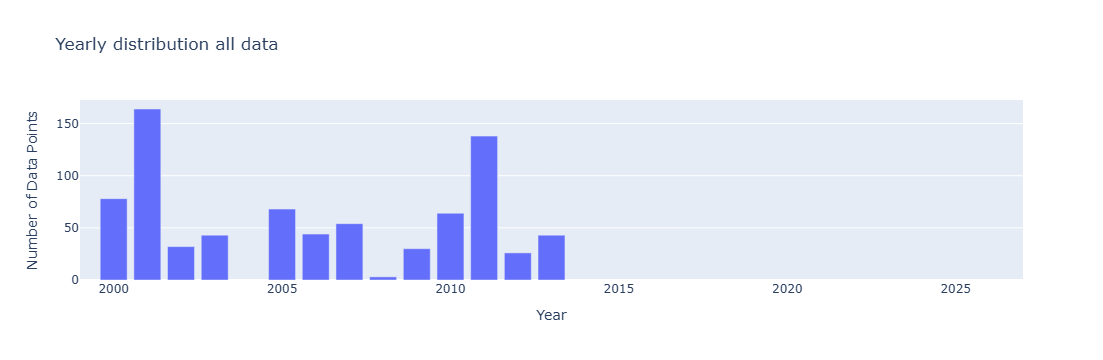

In [3]:
year_test=gloria.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

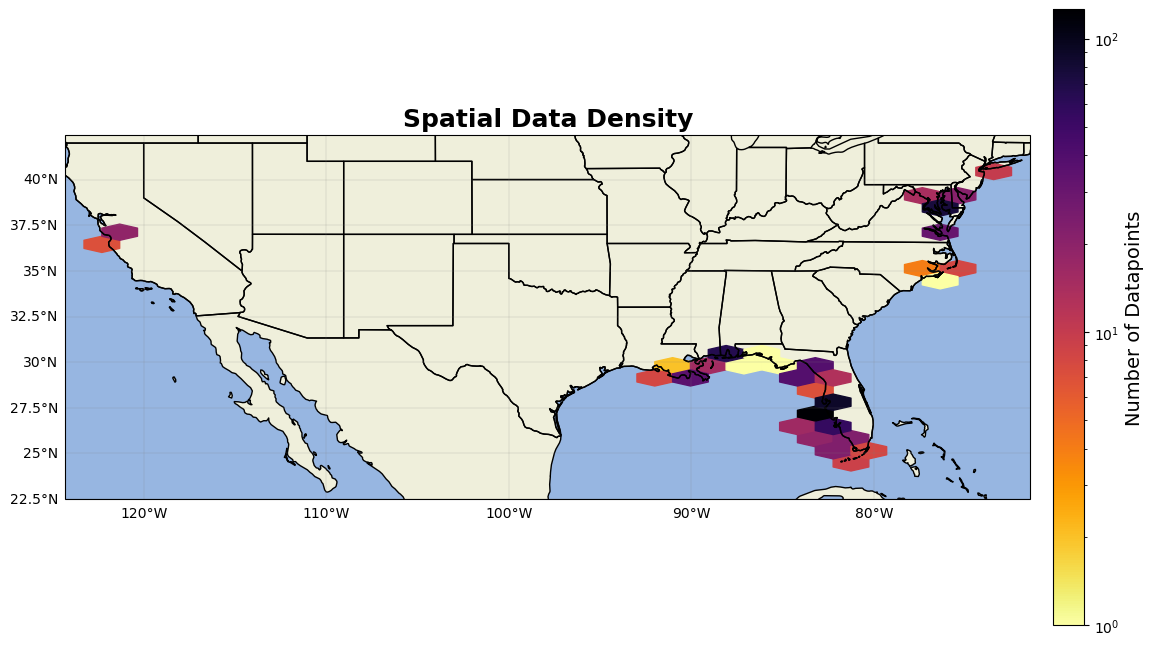

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(25,12), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()